##Final Project: Fed Minutes Text Mining
This project uses text mining tools to investigate the impacts of Fed minutes on stock market and exchange rate

Now, we use six different methods to do sentiment analysis

In [2]:

# =========================
# Install and Import packages
# =========================
!pip install -q FedTools transformers yfinance torch pandas numpy matplotlib seaborn

from FedTools import FederalReserveMins
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
import pandas as pd
import numpy as np
import torch
import re
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# =========================
# Initial Setup
# =========================
pipeline_device = 0 if torch.cuda.is_available() else -1
print(
    f"GPU available: {torch.cuda.is_available()} — using "
    f"{'GPU ⚡' if pipeline_device==0 else 'CPU'}"
    )
torch.set_grad_enabled(False)

start_year = 1993
end_year = 2025

# =========================
# Fetch FED minutes
#: Pre-2017	fomcminutesYYYYMMDD.htm
# 2017-2020: fomchistorical2018.htm
# 2021-current: current link
# =========================
fed_mins = FederalReserveMins(
    main_url='https://www.federalreserve.gov',
    calendar_url='https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm',
    start_year=start_year,
    historical_split=2020,  # after 2020, using current link
    verbose=True,
    thread_num=10
)

dataset = fed_mins.find_minutes()
dataset.index = pd.to_datetime(dataset.index)
dataset = dataset.loc[f"{start_year}-01-01":f"{end_year}-12-31"]

print("\nFed Minutes Samples ...")
print(dataset.head())
print(dataset.tail())
print(f"\nLoaded {len(dataset)} FOMC minutes")

# =========================
# TEXT CHUNKING
# =========================
def chunk_text(text, max_chars=1200):
    """Split on sentence boundaries, up to max_chars per chunk."""
    if pd.isna(text) or not isinstance(text, str):
        return []
    text = re.sub(r'\s+', ' ', text).strip()
    sentences = re.split(r'(?<=[.!?])\s+', text)
    chunks, current = [], ""
    for sent in sentences:
        if len(current) + len(sent) + 1 <= max_chars:
            current = (current + " " + sent).strip()
        else:
            if current:
                chunks.append(current)
            # If a single sentence is too long, hard-split it
            if len(sent) > max_chars:
                for i in range(0, len(sent), max_chars):
                    chunks.append(sent[i:i + max_chars])
            else:
                current = sent
    if current:
        chunks.append(current)
    return chunks

print("\nChunking documents...")
all_chunks, chunk_to_doc = [], []
for idx, text in enumerate(tqdm(dataset['Federal_Reserve_Mins'], desc="Chunking")):
    chunks = chunk_text(text)
    all_chunks.extend(chunks)
    chunk_to_doc.extend([idx] * len(chunks))

print(f"→ {len(all_chunks)} chunks from {len(dataset)} documents")




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 6.3 MB/s eta 0:00:00
GPU available: True — using GPU ⚡
Constructing links between 1993 and 2026
Extracting Federal Reserve Minutes.
Retrieving articles.
.................................................................................................................................................................................................................................................................................
Fed Minutes Samples ...
                                         Federal_Reserve_Mins
1993-02-03  An official website of the United States Gover...
1993-03-23  A meeting of the Federal Open Market Committee...
1993-05-18  A meeting of the Federal Open Market Committee...
1993-07-07  A meeting of the Federal Open Market Committee...
1993-08-17  A meeting of the Federal Open Market Committee...
                                         Federal_Reserve_Mins
2025-06-18  An official website of the United States Gov

Chunking:   0%|          | 0/263 [00:00<?, ?it/s]

→ 52492 chunks from 263 documents


In [5]:
# ==============================================================
# Sentiment Analysis: FinBERT, FinBERT-FOMC, CB_RoBERTA and zero-shot
# ================================================================

# =========================
# Helper: Run Batch Sentiment Analysis
# =========================
def run_sentiment_pipeline(pipe, all_chunks, chunk_to_doc, dataset, pos_col, sign_col, label_map=None):
    """
    label_map: dict mapping the model's label strings to 'Positive'/'Negative'/'Neutral'.
               Pass None to use labels as-is (assumes 'Positive'/'Negative').
    """
    pos_scores_raw = []
    signed_scores_raw = []
    batch_size = 128
    total_chunks = len(all_chunks)
    report_every = 5
    next_report = report_every

    for start in range(0, total_chunks, batch_size):
        end = min(start + batch_size, total_chunks)
        batch = all_chunks[start:end]
        batch_results = pipe(batch, batch_size=batch_size)

        for result in batch_results:
            if isinstance(result, dict):
                result = [result]
            raw_scores = {d['label']: d['score'] for d in result}

            # Remap labels if needed
            if label_map:
                scores = {}
                for raw_label, score in raw_scores.items():
                    mapped = label_map.get(raw_label, raw_label)
                    scores[mapped] = scores.get(mapped, 0.0) + score
            else:
                scores = raw_scores

            pos_scores_raw.append(scores.get('Positive', 0.0))
            signed_scores_raw.append(
                scores.get('Positive', 0.0) - scores.get('Negative', 0.0)
            )

        processed = end
        pct = processed / total_chunks * 100
        if pct >= next_report:
            print(f"  Progress: {next_report}% ({processed:,}/{total_chunks:,} chunks)", flush=True)
            next_report += report_every

    print(f"  ✓ Inference complete (100%)")

    # Aggregate to document level
    doc_pos  = {}
    doc_sign = {}
    for doc_idx, pos, sign in zip(chunk_to_doc, pos_scores_raw, signed_scores_raw):
        doc_pos.setdefault(doc_idx, []).append(pos)
        doc_sign.setdefault(doc_idx, []).append(sign)

    dataset[pos_col]  = [np.mean(doc_pos[i])  if i in doc_pos  else np.nan for i in range(len(dataset))]
    dataset[sign_col] = [np.mean(doc_sign[i]) if i in doc_sign else np.nan for i in range(len(dataset))]

    print(f"  {pos_col} range: [{dataset[pos_col].min():.3f}, {dataset[pos_col].max():.3f}]")
    print(f"  {sign_col} range: [{dataset[sign_col].min():.3f}, {dataset[sign_col].max():.3f}]")
    print(f"  Docs with scores: {dataset[pos_col].notna().sum()}")
    return dataset


# ======================================
# 1. BERT (Base BERT for sentiment)
# ===================================
print("\n[1/6] Running BERT Sentiment (nlptown/bert-base-multilingual-uncased-sentiment)...")
bert_pipe = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=pipeline_device,
    torch_dtype=torch.float16,
    truncation=True,
    padding=True,
    max_length=512,
    batch_size=128,
    top_k=None,                        # return_all_scores
)

# BERT model returns 1-5 star ratings, need to map to Positive/Negative
# Map: 1-2 stars = Negative, 3 stars = Neutral, 4-5 stars = Positive
def map_bert_scores(result):
    """Convert BERT star ratings to Positive/Negative/Neutral"""
    scores = {d['label']: d['score'] for d in result}
    # Map star ratings to sentiment
    neg_score = scores.get('1 star', 0.0) + scores.get('2 stars', 0.0)
    neu_score = scores.get('3 stars', 0.0)
    pos_score = scores.get('4 stars', 0.0) + scores.get('5 stars', 0.0)
    return [
        {'label': 'Negative', 'score': neg_score},
        {'label': 'Neutral', 'score': neu_score},
        {'label': 'Positive', 'score': pos_score}
    ]

# Create wrapper for BERT
class BERTWrapper:
    def __init__(self, pipe):
        self.pipe = pipe
    def __call__(self, texts, batch_size=128):
        results = self.pipe(texts, batch_size=batch_size)
        if isinstance(results, dict):
            results = [results]
        return [map_bert_scores(r) for r in results]

bert_wrapper = BERTWrapper(bert_pipe)

dataset = run_sentiment_pipeline(
    pipe=bert_wrapper,
    all_chunks=all_chunks,
    chunk_to_doc=chunk_to_doc,
    dataset=dataset,
    pos_col='positiveness_bert',
    sign_col='sentiment_bert',
    label_map=None  # Already mapped in wrapper
)

# ===============================
# 2. FinBERT for financial text
# ================================
print("\n[2/6] Running FinBERT (yiyanghkust/finbert-tone)...")
finbert_pipe = pipeline(
    "sentiment-analysis",
    model="yiyanghkust/finbert-tone",
    device=pipeline_device,
    torch_dtype=torch.float16,
    truncation=True,
    padding=True,
    max_length=512,
    batch_size=128,
    top_k=None,
)
dataset = run_sentiment_pipeline(
    pipe=finbert_pipe,
    all_chunks=all_chunks,
    chunk_to_doc=chunk_to_doc,
    dataset=dataset,
    pos_col='positiveness_finbert',
    sign_col='sentiment_finbert',
    label_map=None   # labels already 'Positive', 'Negative', 'Neutral'
)


# =========================================
# 3. FinBERT-FOMC for FOMC
# ========================================
print("\n[3/6] Running FinBERT-FOMC (ZiweiChen/FinBERT-FOMC)...")

# Load the model
fomc_pipe = pipeline(
    "sentiment-analysis",
    model="ZiweiChen/FinBERT-FOMC",
    device=pipeline_device,
    torch_dtype=torch.float16,
    truncation=True,
    padding=True,
    max_length=512,
    batch_size=128,
    top_k=None,
)

# Quick label check to see what the model actually returns
test_result = fomc_pipe(["The Fed raised rates aggressively to combat inflation."])
print(f"  Label check result: {test_result}")
print(f"  Expected format: [{{'label': 'Positive'/'Negative', 'score': 0.xxx}}, ...]")

# No label mapping needed as outputs are 'Positive'/'Negative'/'Neutral' directly
dataset = run_sentiment_pipeline(
    pipe=fomc_pipe,
    all_chunks=all_chunks,
    chunk_to_doc=chunk_to_doc,
    dataset=dataset,
    pos_col='positiveness_bert_fomc',
    sign_col='sentiment_bert_fomc',
    label_map=None   # No mapping needed
)


# =====================================
# 4. RoBERTa (Base RoBERTa for sentiment)
# ======================================
print("\n[4/6] Running RoBERTa Sentiment (cardiffnlp/twitter-roberta-base-sentiment)...")
roberta_pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    device=pipeline_device,
    torch_dtype=torch.float16,
    truncation=True,
    max_length=512,
    padding=True,
    batch_size=128,
    top_k=None,
)

# RoBERTa model returns LABEL_0 (Negative), LABEL_1 (Neutral), LABEL_2 (Positive)
label_map_roberta = {
    'LABEL_0': 'Negative',
    'LABEL_1': 'Neutral',
    'LABEL_2': 'Positive'
}

dataset = run_sentiment_pipeline(
    pipe=roberta_pipe,
    all_chunks=all_chunks,
    chunk_to_doc=chunk_to_doc,
    dataset=dataset,
    pos_col='positiveness_roberta',
    sign_col='sentiment_roberta',
    label_map=label_map_roberta
)


# ================================================
# 5. CentralBankRoBERTa - Sentiment Classifier
# ================================================
print("\n[5/6] Running CentralBankRoBERTa Sentiment Classifier ....")

# Load the model
cb_sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="Moritz-Pfeifer/CentralBankRoBERTa-sentiment-classifier",
    device=pipeline_device,
    torch_dtype=torch.float16,
    truncation=True,
    max_length=512,
    padding=True,
    batch_size=128,
    top_k=None,
)

# Quick label check to see what the model actually returns
test_result = cb_sentiment_pipe(["The Fed raised rates aggressively to combat inflation."])
print(f"  Label check result: {test_result}")
print(f"  Expected format: [{{'label': 'Positive'/'Negative', 'score': 0.xxx}}, ...]")

# Define label map to convert lowercase to uppercase
label_map = {'positive': 'Positive',
             'negative': 'Negative',
            }
# Run sentiment pipeline with label mapping
dataset = run_sentiment_pipeline(
    pipe=cb_sentiment_pipe,
    all_chunks=all_chunks,
    chunk_to_doc=chunk_to_doc,
    dataset=dataset,
    pos_col='positiveness_cbroberta',
    sign_col='sentiment_cbroberta',
    label_map=label_map    # Map lowercase to uppercase
)

# ================================
# 6. Zero-Shot Classification
# ================================
print("\n[6/6] Running Zero-Shot Classifier")
from transformers import pipeline as hf_pipeline

zeroshot_pipe = hf_pipeline(
    "zero-shot-classification",
    model="typeform/distilbert-base-uncased-mnli",  # Fast and simple
    device=pipeline_device,
    batch_size=64,   # zero-shot is heavier; smaller batch
)
candidate_labels = ["positive", "negative", "neutral"]

pos_scores_raw_zs  = []
signed_scores_raw_zs = []
total_chunks = len(all_chunks)
batch_size_zs = 64  # Match batch size 16
report_every = 5
next_report = report_every

for start in range(0, total_chunks, batch_size_zs):
    end = min(start + batch_size_zs, total_chunks)
    batch = all_chunks[start:end]

    results = zeroshot_pipe(batch, candidate_labels=candidate_labels, multi_label=False)
    if isinstance(results, dict):   # single-item edge case
        results = [results]

    for res in results:
        score_map = dict(zip(res['labels'], res['scores']))
        pos  = score_map.get('positive', 0.0)
        neg  = score_map.get('negative', 0.0)
        pos_scores_raw_zs.append(pos)
        signed_scores_raw_zs.append(pos - neg)

    processed = end
    pct = processed / total_chunks * 100
    if pct >= next_report:
        print(f"  Progress: {next_report}% ({processed:,}/{total_chunks:,} chunks)", flush=True)
        next_report += report_every

print("  ✓ Zero-shot inference complete (100%)")

# Aggregate zero-shot to document level
doc_pos_zs  = {}
doc_sign_zs = {}
for doc_idx, pos, sign in zip(chunk_to_doc, pos_scores_raw_zs, signed_scores_raw_zs):
    doc_pos_zs.setdefault(doc_idx, []).append(pos)
    doc_sign_zs.setdefault(doc_idx, []).append(sign)

dataset['positiveness_zero_shot'] = [np.mean(doc_pos_zs[i])  if i in doc_pos_zs  else np.nan for i in range(len(dataset))]
dataset['sentiment_zero_shot']    = [np.mean(doc_sign_zs[i]) if i in doc_sign_zs else np.nan for i in range(len(dataset))]

print(f"  positiveness_zero_shot range: [{dataset['positiveness_zero_shot'].min():.3f}, {dataset['positiveness_zero_shot'].max():.3f}]")
print(f"  sentiment_zero_shot range:    [{dataset['sentiment_zero_shot'].min():.3f}, {dataset['sentiment_zero_shot'].max():.3f}]")

print("\n" + "="*60)
print("✓ ALL SIX SENTIMENT ANALYSIS METHODS COMPLETED SUCCESSFULLY")


[1/6] Running BERT Sentiment (nlptown/bert-base-multilingual-uncased-sentiment)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Progress: 5% (2,688/52,492 chunks)
  Progress: 10% (5,376/52,492 chunks)
  Progress: 15% (7,936/52,492 chunks)
  Progress: 20% (10,624/52,492 chunks)
  Progress: 25% (13,184/52,492 chunks)
  Progress: 30% (15,872/52,492 chunks)
  Progress: 35% (18,432/52,492 chunks)
  Progress: 40% (21,120/52,492 chunks)
  Progress: 45% (23,680/52,492 chunks)
  Progress: 50% (26,368/52,492 chunks)
  Progress: 55% (28,928/52,492 chunks)
  Progress: 60% (31,616/52,492 chunks)
  Progress: 65% (34,176/52,492 chunks)
  Progress: 70% (36,864/52,492 chunks)
  Progress: 75% (39,424/52,492 chunks)
  Progress: 80% (42,112/52,492 chunks)
  Progress: 85% (44,672/52,492 chunks)
  Progress: 90% (47,360/52,492 chunks)
  Progress: 95% (49,920/52,492 chunks)
  Progress: 100% (52,492/52,492 chunks)
  ✓ Inference complete (100%)
  positiveness_bert range: [0.144, 0.354]
  sentiment_bert range: [-0.441, -0.005]
  Docs with scores: 263

[2/6] Running FinBERT (yiyanghkust/finbert-tone)...


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/258 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

  Progress: 5% (2,688/52,492 chunks)
  Progress: 10% (5,312/52,492 chunks)
  Progress: 15% (7,936/52,492 chunks)
  Progress: 20% (10,560/52,492 chunks)
  Progress: 25% (13,184/52,492 chunks)
  Progress: 30% (15,808/52,492 chunks)
  Progress: 35% (18,432/52,492 chunks)
  Progress: 40% (21,056/52,492 chunks)
  Progress: 45% (23,680/52,492 chunks)
  Progress: 50% (26,304/52,492 chunks)
  Progress: 55% (28,928/52,492 chunks)
  Progress: 60% (31,552/52,492 chunks)
  Progress: 65% (34,176/52,492 chunks)
  Progress: 70% (36,800/52,492 chunks)
  Progress: 75% (39,424/52,492 chunks)
  Progress: 80% (42,048/52,492 chunks)
  Progress: 85% (44,672/52,492 chunks)
  Progress: 90% (47,296/52,492 chunks)
  Progress: 95% (49,920/52,492 chunks)
  Progress: 100% (52,492/52,492 chunks)
  ✓ Zero-shot inference complete (100%)
  positiveness_zero_shot range: [0.229, 0.351]
  sentiment_zero_shot range:    [-0.228, -0.001]

✓ ALL SIX SENTIMENT ANALYSIS METHODS COMPLETED SUCCESSFULLY


In [12]:
# ==========================================
# Export CSV to Google Drive (Streamlined)
# ==========================================
import os
from google.colab import drive

# 1. Authorize and connect your Google Drive to the Colab
print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

# 2. Setup your destination folder
output_folder = '/content/drive/MyDrive/'
os.makedirs(output_folder, exist_ok=True)

# 3. Prepare the DataFrame for export
def get_release_date(df):
    """
    Calculate release date based on meeting date.
    - After 2004 (2005+): release is 3 weeks (21 days) later, adjusted to Wednesday if needed
    - 1997-2004: release is 2 days after the subsequent meeting
    - 1993-1996: release is 3 days after the subsequent meeting
    """
    release_dates = []
    dates = pd.to_datetime(df['date'])

    for i, d in enumerate(dates):
        if d.year > 2004:  # 2005 and later
            # Calculate release date and adjust to Wednesday if necessary
            release_date = d + pd.Timedelta(weeks=3)
            if release_date.weekday() != 2:   # weekday=2 for Wednesday
                release_date += pd.Timedelta(days=(2 - release_date.weekday()))
            release_dates.append(release_date)
        elif d.year <= 2004 and i + 1 < len(dates):   # Before 2004 using next meeting date
            next_meeting = dates[i + 1]
            if d.year >= 1997:  # 1997-2004
                release_dates.append(next_meeting + pd.Timedelta(days=2))  # Next meeting + 2 days
            else:  # 1993-1996
                release_dates.append(next_meeting + pd.Timedelta(days=3))  # Next meeting + 3 days
        else:
            release_dates.append(pd.NaT)  # Return NaT if year of last meeting < 2004

    return release_dates

# Reset index to use date as a column
export_csv = dataset.reset_index()
export_csv = export_csv.rename(columns={'index': 'date'})

# Calculate release date for each meeting
export_csv['date_release'] = get_release_date(export_csv)

# Define columns to export
export_cols = ['date', 'date_release',
               'positiveness_bert',     'sentiment_bert',
               'positiveness_finbert',  'sentiment_finbert',
               'positiveness_bert_fomc','sentiment_bert_fomc',
               'positiveness_roberta',  'sentiment_roberta',
               'positiveness_cbroberta','sentiment_cbroberta',
               'positiveness_zero_shot','sentiment_zero_shot']

# Keep only columns that actually exist in the dataframe
export_cols = [c for c in export_cols if c in export_csv.columns]


# 4. Save the single master CSV file
output_path = os.path.join(output_folder, "fomc_sentiment_data.csv")
export_csv[export_cols].to_csv(output_path, index=False)

print(f"\n✓ Successfully exported to Google Drive: {output_path}")
print(f"  Final File Shape: {export_csv[export_cols].shape}")
print("\nFirst 5 rows of exported data:")
print(export_csv[export_cols].head())


# =========================
# Summary
# =========================
# Summary of Positiveness measure from 0 to 1
print("\n" + "="*60)
print("Summary of Positiveness ")
print("="*60)
cols_pos = [
    'positiveness_bert',      'positiveness_finbert',
    'positiveness_bert_fomc', 'positiveness_roberta',
    'positiveness_cbroberta', 'positiveness_zero_shot',
]
summary_pos = dataset[cols_pos].describe().round(4).T  #Transpose
summary_pos =summary_pos[['count', 'mean', 'std', 'min', 'max']]
print(summary_pos)

# Correlation of positiveness
print("\n" + "="*60)
print("Correlation of Positiveness across Six Methods")
print("="*60)

corr_pos = dataset[cols_pos].corr().round(3)
corr_pos.columns = ['bert', 'finbert', 'bert_fomc', 'roberta', 'cbroberta', 'zero_shot']
corr_pos.index = ['bert', 'finbert', 'bert_fomc', 'roberta', 'cbroberta', 'zero_shot']
print(corr_pos)


# Summary of Sentiment indicator from -1 to 1
print("\n" + "="*60)
print("Summary of Sentiment ")
print("="*60)
cols_sent = ['sentiment_bert',       'sentiment_finbert',
             'sentiment_bert_fomc',  'sentiment_roberta',
             'sentiment_cbroberta',  'sentiment_zero_shot',
            ]
summary_sent = dataset[cols_sent].describe().round(4).T  #Transpose
summary_sent =summary_sent[['count', 'mean', 'std', 'min', 'max']]
print(summary_sent)


# Correlation of sentiment
print("\n" + "="*60)
print("Correlation of Sentiment across Six Methods")
print("="*60)

corr_sent = dataset[cols_sent].corr().round(3)
corr_sent.columns = ['bert', 'finbert', 'bert_fomc', 'roberta', 'cbroberta', 'zero_shot']
corr_sent.index = ['bert', 'finbert', 'bert_fomc', 'roberta', 'cbroberta', 'zero_shot']
print(corr_sent)

Mounting Google Drive...
Mounted at /content/drive

✓ Successfully exported to Google Drive: /content/drive/MyDrive/fomc_sentiment_data.csv
  Final File Shape: (263, 14)

First 5 rows of exported data:
        date date_release  positiveness_bert  sentiment_bert  \
0 1993-02-03   1993-03-26           0.279935       -0.175300   
1 1993-03-23   1993-05-21           0.220515       -0.244863   
2 1993-05-18   1993-07-10           0.200905       -0.288740   
3 1993-07-07   1993-08-20           0.224636       -0.225363   
4 1993-08-17   1993-09-24           0.203937       -0.290921   

   positiveness_finbert  sentiment_finbert  positiveness_bert_fomc  \
0              0.406426           0.213139                0.402122   
1              0.406003           0.126396                0.363191   
2              0.225616          -0.289228                0.225936   
3              0.385903           0.149705                0.311489   
4              0.345098           0.015009                0.303

Now show time series plots with business cycle indicators

Data shape: (263, 7)
Date range: 1993-02-03 00:00:00 to 2025-12-10 00:00:00


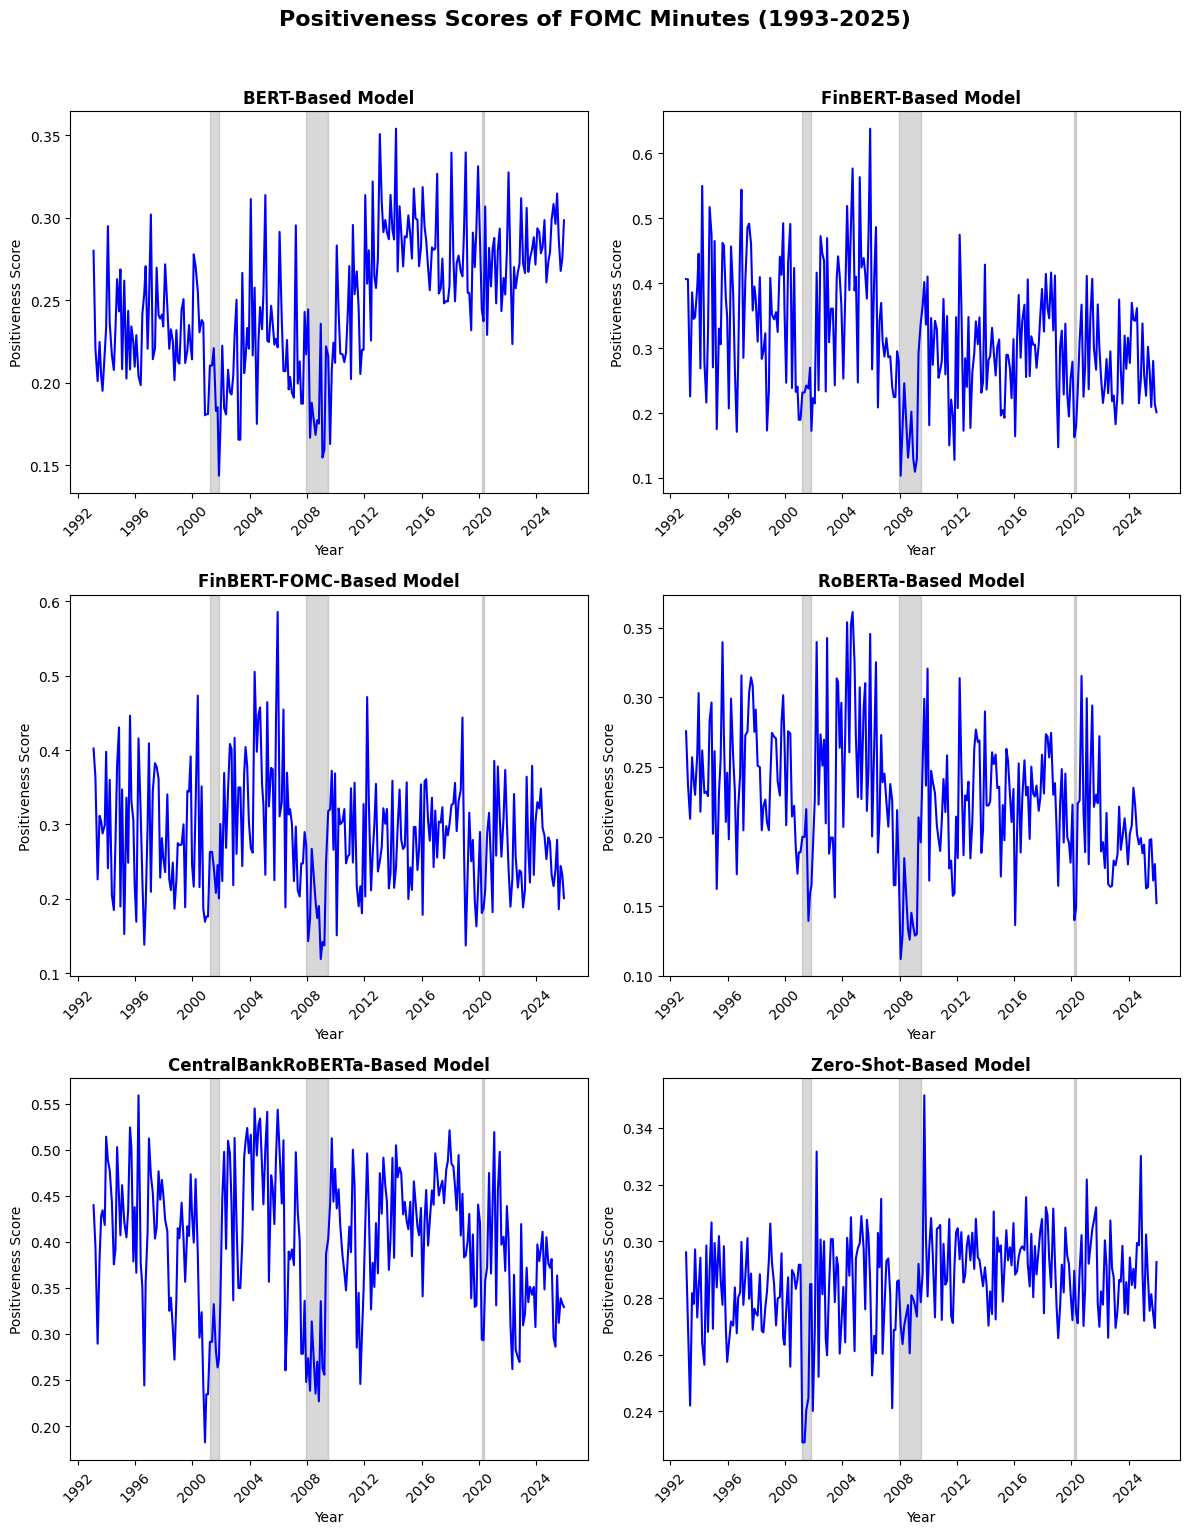

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# =========================
# Step 1: Prepare data
# =========================
data = dataset.reset_index().rename(columns={'index': 'date'})

cols_pos = [
    'positiveness_bert', 'positiveness_finbert',
    'positiveness_bert_fomc', 'positiveness_roberta',
    'positiveness_cbroberta', 'positiveness_zero_shot'
]

data = data[['date'] + cols_pos].copy()
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date')
print(f"Data shape: {data.shape}")
print(f"Date range: {data['date'].min()} to {data['date'].max()}")

# =========================
# Step 2: NBER Recession periods (1993-2025)
# =========================
recession_periods = [
    ('1990-07-01', '1991-03-01'),   # Early 1990s recession
    ('2001-03-01', '2001-11-01'),   # Dot-com recession
    ('2007-12-01', '2009-06-01'),   # Great Recession
    ('2020-02-01', '2020-04-01'),   # COVID-19 recession
]

# Add recession indicator
data['is_recession'] = 0
for start_date, end_date in recession_periods:
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    data.loc[(data['date'] >= start) & (data['date'] <= end), 'is_recession'] = 1

# Create continuous recession periods for shading
recession_shades = []
in_recession = False
start_date = None

for idx, row in data.iterrows():
    if row['is_recession'] == 1 and not in_recession:
        start_date = row['date']
        in_recession = True
    elif row['is_recession'] == 0 and in_recession:
        recession_shades.append((start_date, row['date']))
        in_recession = False

if in_recession:
    recession_shades.append((start_date, data['date'].iloc[-1]))

# =========================
# Step 3: Create 3x2 subplot with recession shading
# =========================
positiveness_measures = {
    'positiveness_bert': 'BERT',
    'positiveness_finbert': 'FinBERT',
    'positiveness_bert_fomc': 'FinBERT-FOMC',
    'positiveness_roberta': 'RoBERTa',
    'positiveness_cbroberta': 'CentralBankRoBERTa',
    'positiveness_zero_shot': 'Zero-Shot'
}

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()

for idx, (col, label) in enumerate(positiveness_measures.items()):
    ax = axes[idx]

    # Plot time series
    ax.plot(data['date'], data[col], linewidth=1.5, color='blue')

    # Add grey recession shading
    for start, end in recession_shades:
        ax.axvspan(start, end, alpha=0.3, color='gray', label='Recession' if idx == 0 else "")

    # Customize
    ax.set_title(f'{label}-Based Model', fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Positiveness Score')
    #ax.grid(True, alpha=0.3)
    #if idx == 0:
    #    ax.legend(loc='upper right', fontsize=8)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Positiveness Scores of FOMC Minutes (1993-2025)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('positiveness_recession_analysis.png', dpi=150, bbox_inches='tight')
plt.show()